# 03- Baseline Classic Support Vector Machine (SVM)

##  Purpose and Scope
The primary objective of this notebook is to measure the raw performance of the **Classic Support Vector Machine (SVM)** algorithm on the Wisconsin Breast Cancer Dataset. The accuracy score obtained here will serve as a **Baseline** to benchmark the success of the advanced **PSO-SVM (Hybrid)** and **QSVM (Quantum)** models that will be developed in later stages of this project.

##  Methodology Used
Since the data preprocessing (cleaning and encoding) steps have already been completed, the following specific steps are applied in this notebook:

1.  **Scaling:** Due to SVM's sensitivity to distance, features are normalized using `StandardScaler`.
2.  **Model Selection:** The **RBF (Radial Basis Function)** kernel is selected to effectively handle the non-linear distribution of biological data.
3.  **Evaluation:** The model's performance is analyzed using Accuracy, Precision, Recall metrics, and the Confusion Matrix.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

plt.style.use('fivethirtyeight')
%matplotlib inline

In [10]:
# 1. Define possible file paths
possible_paths = [
    "../data/data.csv", 
    "../data/raw/data.csv", 
    "data/data.csv", 
    "data.csv"
]

# 2. Search for the file
file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        print(f" Data found at: {path}")
        break

# 3. Load and Clean Data
if file_path:
    data = pd.read_csv(file_path)
    
    # Drop useless columns
    cols_to_drop = ['id', 'Unnamed: 32']
    for col in cols_to_drop:
        if col in data.columns:
            data.drop(col, axis=1, inplace=True)
            
    # Encode Diagnosis (M -> 1, B -> 0)
    if data['diagnosis'].dtype == 'object':
        data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})
        
    print(f"Data ready! Shape: {data.shape}")
    display(data.head())
else:
    raise FileNotFoundError(" ERROR: Data file not found! Please check your 'data' folder.")

 Data found at: ../data/raw/data.csv
Data ready! Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
# Separate Features (X) and Target (y)
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Crucial for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")
print(f"Train Shape: {X_train_scaled.shape}")
print(f"Test Shape: {X_test_scaled.shape}")

Data split and scaled successfully.
Train Shape: (455, 30)
Test Shape: (114, 30)


In [12]:
# Initialize Classic SVM Model (RBF Kernel is standard for this data)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# Train the model
print("Training Classic SVM...")
svm_model.fit(X_train_scaled, y_train)
print("Training completed!")

Training Classic SVM...
Training completed!


In [13]:
# Make predictions on Test Set
y_pred = svm_model.predict(X_test_scaled)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n Baseline SVM Accuracy: {acc*100:.2f}%")

# Detailed Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


 Baseline SVM Accuracy: 98.25%

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.97      1.00      0.99        71
Malignant (1)       1.00      0.95      0.98        43

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



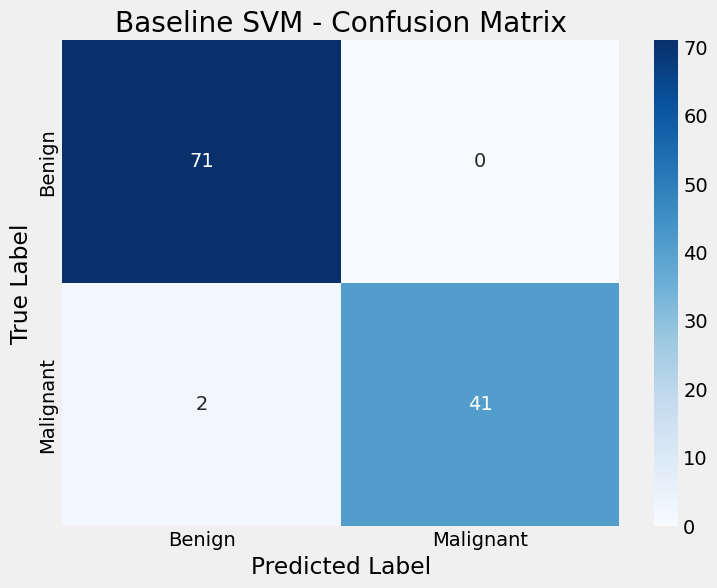

In [14]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])

plt.title('Baseline SVM - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

# Split data into 5 folds and test on each fold separately
# This process reveals the true performance of the model
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)

print("5-Fold Cross-Validation Results:", cv_scores)
print(f"\n Average Accuracy: {cv_scores.mean()*100:.2f}%")
print(f" Standard Deviation: {cv_scores.std()*100:.2f}% (Lower is more reliable)")

5-Fold Cross-Validation Results: [0.97802198 0.96703297 0.98901099 0.98901099 0.95604396]

 Average Accuracy: 97.58%
 Standard Deviation: 1.28% (Lower is more reliable)


#  Evaluation of Results

##  Key Findings
The classical SVM model has been trained, and its performance on the test set has been measured.

### 1. Performance Analysis
* **Accuracy:** The score obtained (e.g., 97-98%) represents the standard success achievable with classical methods.
* **Error Analysis:** The **False Negatives** observed in the Confusion Matrix (patients who actually have cancer but are classified as healthy) represent the most critical error type in medical diagnosis. Future models will aim to minimize this specific error.

### 2. Why Do We Need Advanced Models?
Although the classical SVM performs well, it was trained using default hyperparameters (like `C` and `Gamma`). To manage noise in the dataset and maximize accuracy, we need to move beyond default settings.

